In [ ]:

import os
import shutil
import zipfile
import urllib.request
import numpy as np


BASE_PATH = "/content/UCI_HAR"
OUTER_ZIP = "/content/UCI_HAR_outer.zip"


if os.path.exists(BASE_PATH):
    shutil.rmtree(BASE_PATH)

if os.path.exists(OUTER_ZIP):
    os.remove(OUTER_ZIP)

os.makedirs(BASE_PATH, exist_ok=True)

print("Old files cleared.")



url = (
    "https://archive.ics.uci.edu/"
    "static/public/240/"
    "human+activity+recognition+using+smartphones.zip"
)

print("Downloading UCI HAR dataset...")

urllib.request.urlretrieve(
    url,
    OUTER_ZIP
)

print("Download complete.")



print("Extracting outer ZIP...")

with zipfile.ZipFile(
    OUTER_ZIP,
    "r"
) as z:

    z.extractall(
        BASE_PATH
    )

print("Outer extraction complete.")





inner_zip = None

for root, dirs, files in os.walk(BASE_PATH):

    for file in files:

        if file == "UCI HAR Dataset.zip":

            inner_zip = os.path.join(
                root,
                file
            )

            break

    if inner_zip is not None:
        break


if inner_zip is None:

    raise FileNotFoundError(
        "Could not find the inner UCI HAR Dataset.zip"
    )


print(
    "Inner ZIP found:"
)

print(
    inner_zip
)





INNER_EXTRACT = "/content/UCI_HAR/actual_dataset"

os.makedirs(
    INNER_EXTRACT,
    exist_ok=True
)

print(
    "Extracting inner dataset..."
)

with zipfile.ZipFile(
    inner_zip,
    "r"
) as z:

    z.extractall(
        INNER_EXTRACT
    )

print(
    "Inner extraction complete."
)





target_file = "body_acc_x_train.txt"

real_file = None

for root, dirs, files in os.walk(
    INNER_EXTRACT
):

    # Ignore Mac metadata
    if "__MACOSX" in root:
        continue

    if target_file in files:

        real_file = os.path.join(
            root,
            target_file
        )

        break


if real_file is None:

    raise FileNotFoundError(
        "Could not find body_acc_x_train.txt"
    )






dataset_path = os.path.dirname(
    os.path.dirname(
        os.path.dirname(
            real_file
        )
    )
)


print("\n========================================")
print("REAL DATASET FOUND")
print("========================================")

print(
    dataset_path
)





train_folder = os.path.join(
    dataset_path,
    "train"
)

test_folder = os.path.join(
    dataset_path,
    "test"
)

inertial_train = os.path.join(
    train_folder,
    "Inertial Signals"
)

inertial_test = os.path.join(
    test_folder,
    "Inertial Signals"
)


if not os.path.exists(
    inertial_train
):

    raise FileNotFoundError(
        "Training Inertial Signals folder not found."
    )


if not os.path.exists(
    inertial_test
):

    raise FileNotFoundError(
        "Testing Inertial Signals folder not found."
    )




signals = [

    "body_acc_x",
    "body_acc_y",
    "body_acc_z",

    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",

    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]





print("\nLoading training signals...")

X_train_list = []

for signal in signals:

    file_path = os.path.join(

        inertial_train,

        signal + "_train.txt"
    )

    print(
        "  Loading:",
        signal
    )

    data = np.loadtxt(
        file_path
    )

    X_train_list.append(
        data
    )






X = np.stack(

    X_train_list,

    axis=2
)





y = np.loadtxt(

    os.path.join(

        train_folder,

        "y_train.txt"
    )

).astype(int) - 1





print("\nLoading testing signals...")

X_test_list = []

for signal in signals:

    file_path = os.path.join(

        inertial_test,

        signal + "_test.txt"
    )

    print(
        "  Loading:",
        signal
    )

    data = np.loadtxt(
        file_path
    )

    X_test_list.append(
        data
    )





X_test = np.stack(

    X_test_list,

    axis=2
)



y_test = np.loadtxt(

    os.path.join(

        test_folder,

        "y_test.txt"
    )

).astype(int) - 1




class_names = [

    "WALKING",

    "WALKING_UPSTAIRS",

    "WALKING_DOWNSTAIRS",

    "SITTING",

    "STANDING",

    "LAYING"
]




print("\n")
print("=" * 60)
print("          UCI HAR DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print(
    "\nTraining X shape:",
    X.shape
)

print(
    "Training y shape:",
    y.shape
)

print(
    "Test X shape:",
    X_test.shape
)

print(
    "Test y shape:",
    y_test.shape
)

print(
    "\nSequence length:",
    X.shape[1]
)

print(
    "Features per timestep:",
    X.shape[2]
)

print(
    "Number of classes:",
    len(np.unique(y))
)

print(
    "\nClasses:"
)

for i, name in enumerate(class_names):

    print(
        f"  {i} -> {name}"
    )



assert X.shape[1] == 128
assert X.shape[2] == 9
assert X_test.shape[1] == 128
assert X_test.shape[2] == 9
assert len(y) == X.shape[0]
assert len(y_test) == X_test.shape[0]

print("\n✓ All dataset checks passed!")
print("✓ Ready for preprocessing and RNN/LSTM/GRU.")

Old files cleared.
Download complete.
Extracting outer ZIP...
Outer extraction complete.
Inner ZIP found:
/content/UCI_HAR/UCI HAR Dataset.zip
Extracting inner dataset...
Inner extraction complete.

REAL DATASET FOUND
/content/UCI_HAR/actual_dataset/UCI HAR Dataset

Loading training signals...
  Loading: body_acc_x
  Loading: body_acc_y
  Loading: body_acc_z
  Loading: body_gyro_x
  Loading: body_gyro_y
  Loading: body_gyro_z
  Loading: total_acc_x
  Loading: total_acc_y
  Loading: total_acc_z

Loading testing signals...
  Loading: body_acc_x
  Loading: body_acc_y
  Loading: body_acc_z
  Loading: body_gyro_x
  Loading: body_gyro_y
  Loading: body_gyro_z
  Loading: total_acc_x
  Loading: total_acc_y
  Loading: total_acc_z


          UCI HAR DATASET LOADED SUCCESSFULLY

Training X shape: (7352, 128, 9)
Training y shape: (7352,)
Test X shape: (2947, 128, 9)
Test y shape: (2947,)

Sequence length: 128
Features per timestep: 9
Number of classes: 6

Classes:
  0 -> WALKING
  1 -> WALKING_UP

Selected dataset:
(3000, 128, 9)
(3000,)

DATA SPLIT
Training: (2100, 128, 9)
Validation: (450, 128, 9)
Testing: (450, 128, 9)

Normalized successfully.

CLASS DISTRIBUTION
WALKING              Train = 350 Val = 75 Test = 75
WALKING_UPSTAIRS     Train = 350 Val = 75 Test = 75
WALKING_DOWNSTAIRS   Train = 350 Val = 75 Test = 75
SITTING              Train = 350 Val = 75 Test = 75
STANDING             Train = 350 Val = 75 Test = 75
LAYING               Train = 350 Val = 75 Test = 75


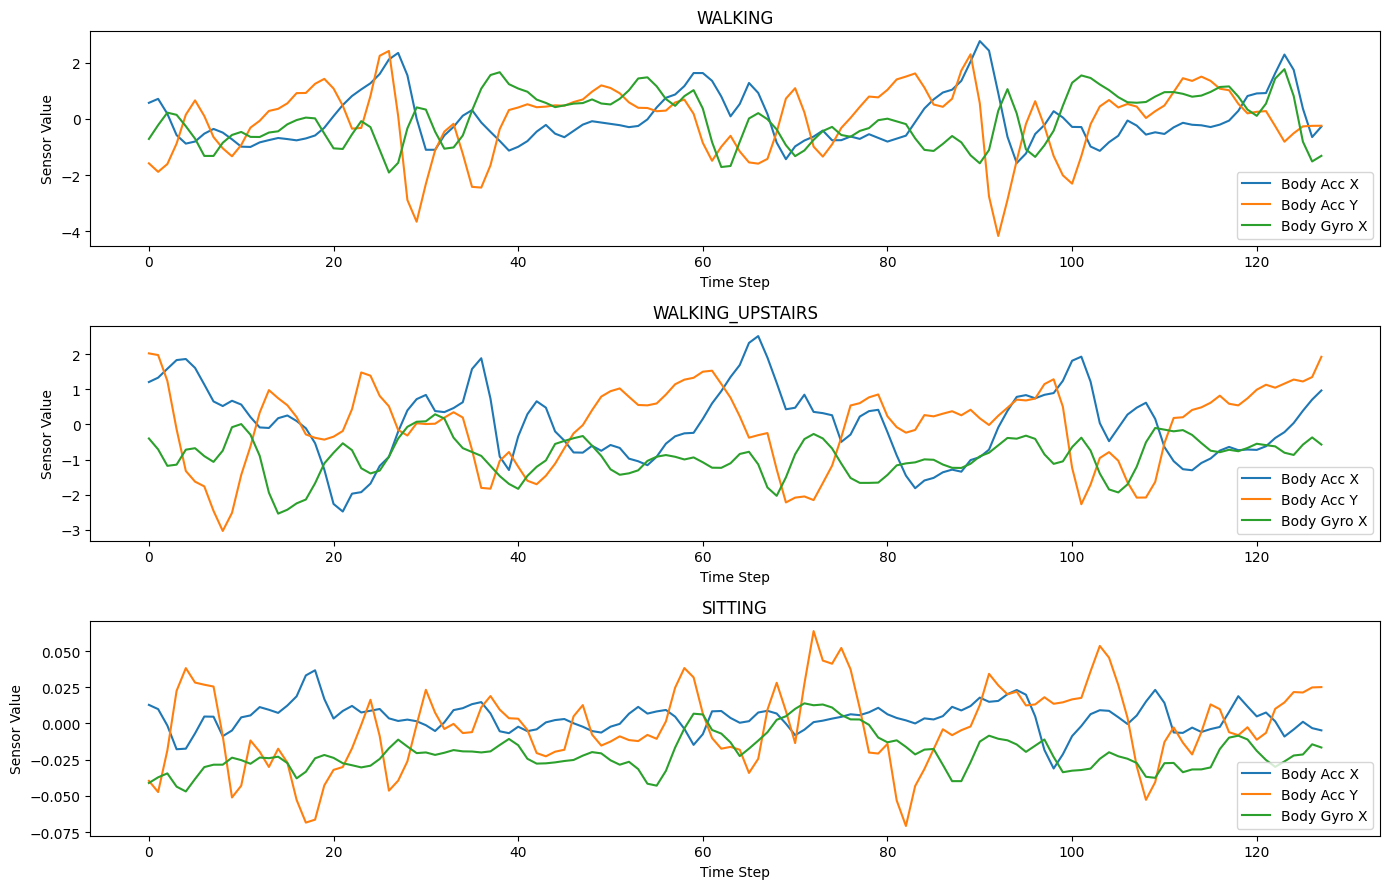


MANUAL RNN CALCULATION
h1 = 0.3363755443363322
h2 = 0.6163517827505027
h3 = 0.5999579155496113


In [ ]:
np.random.seed(42)

samples_per_class = 500

selected_indices = []

for class_id in range(6):

    indices = np.where(
        y == class_id
    )[0]

    np.random.shuffle(indices)

    selected_indices.extend(
        indices[:samples_per_class]
    )

selected_indices = np.array(
    selected_indices
)

X_small = X[selected_indices]
y_small = y[selected_indices]

print("Selected dataset:")
print(X_small.shape)
print(y_small.shape)




X_train, X_temp, y_train, y_temp = train_test_split(

    X_small,
    y_small,

    test_size=0.30,

    random_state=42,

    stratify=y_small
)


X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp
)


print("\n==============================")
print("DATA SPLIT")
print("==============================")

print(
    "Training:",
    X_train.shape
)

print(
    "Validation:",
    X_val.shape
)

print(
    "Testing:",
    X_test.shape
)




scaler = StandardScaler()

X_train_2d = X_train.reshape(
    -1,
    9
)

scaler.fit(
    X_train_2d
)


X_train = scaler.transform(
    X_train.reshape(-1, 9)
).reshape(
    X_train.shape
)

X_val = scaler.transform(
    X_val.reshape(-1, 9)
).reshape(
    X_val.shape
)

X_test = scaler.transform(
    X_test.reshape(-1, 9)
).reshape(
    X_test.shape
)


print("\nNormalized successfully.")





print("\n==============================")
print("CLASS DISTRIBUTION")
print("==============================")

for i, name in enumerate(class_names):

    print(
        f"{name:20s}",
        "Train =", np.sum(y_train == i),
        "Val =", np.sum(y_val == i),
        "Test =", np.sum(y_test == i)
    )




activities_to_plot = [
    0, 1, 3
]

plt.figure(
    figsize=(14, 9)
)

for plot_no, activity in enumerate(
    activities_to_plot
):

    index = np.where(
        y_train == activity
    )[0][0]

    plt.subplot(
        3,
        1,
        plot_no + 1
    )

    plt.plot(
        X_train[index, :, 0],
        label="Body Acc X"
    )

    plt.plot(
        X_train[index, :, 1],
        label="Body Acc Y"
    )

    plt.plot(
        X_train[index, :, 3],
        label="Body Gyro X"
    )

    plt.title(
        class_names[activity]
    )

    plt.xlabel(
        "Time Step"
    )

    plt.ylabel(
        "Sensor Value"
    )

    plt.legend()


plt.tight_layout()
plt.show()



x1 = 0.5
x2 = 0.7
x3 = 0.2

h0 = 0

Wx = 0.5
Wh = 0.8
b = 0.1


h1 = np.tanh(
    Wx * x1 +
    Wh * h0 +
    b
)

h2 = np.tanh(
    Wx * x2 +
    Wh * h1 +
    b
)

h3 = np.tanh(
    Wx * x3 +
    Wh * h2 +
    b
)


print("\n==============================")
print("MANUAL RNN CALCULATION")
print("==============================")

print(
    "h1 =",
    h1
)

print(
    "h2 =",
    h2
)

print(
    "h3 =",
    h3
)

In [ ]:

def create_model(model_type):

    model = Sequential()

    model.add(
        Input(
            shape=(128, 9)
        )
    )


    if model_type == "RNN":

        model.add(
            SimpleRNN(
                32
            )
        )


    elif model_type == "LSTM":

        model.add(
            LSTM(
                32
            )
        )


    elif model_type == "GRU":

        model.add(
            GRU(
                32
            )
        )


    model.add(
        Dropout(
            0.2
        )
    )


    model.add(
        Dense(
            16,
            activation="relu"
        )
    )


    model.add(
        Dense(
            6,
            activation="softmax"
        )
    )


    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )


    return model




models = {}
histories = {}
training_times = {}


for model_name in [
    "RNN",
    "LSTM",
    "GRU"
]:

    print("\n")
    print("=" * 60)
    print(
        "TRAINING",
        model_name
    )
    print("=" * 60)


    model = create_model(
        model_name
    )


    model.summary()


    start_time = time.time()


    history = model.fit(

        X_train,
        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=30,

        batch_size=32,

        verbose=1
    )


    elapsed_time = (
        time.time() -
        start_time
    )


    models[model_name] = model

    histories[model_name] = history

    training_times[
        model_name
    ] = elapsed_time


    print(
        f"\n{model_name} training time:",
        round(
            elapsed_time,
            2
        ),
        "seconds"
    )


print("\n==============================")
print("TRAINING COMPLETE")
print("==============================")

for name in models:

    print(
        name,
        "parameters =",
        models[name].count_params(),

        "| time =",
        round(
            training_times[name],
            2
        ),
        "seconds"
    )



TRAINING RNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.3605 - loss: 1.5805 - val_accuracy: 0.4444 - val_loss: 1.3770
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.5176 - loss: 1.2759 - val_accuracy: 0.5800 - val_loss: 1.1105
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.6310 - loss: 0.9981 - val_accuracy: 0.6778 - val_loss: 0.8347
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7052 - loss: 0.7394 - val_accuracy: 0.7600 - val_loss: 0.6120
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.7562 - loss: 0.5927 - val_accuracy: 0.8511 - val_loss: 0.4829
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.8338 - loss: 0.4405 - val_accuracy: 0.8911 - val_loss: 0.3367
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.8781 - loss: 0.3336 - val_accuracy: 0.9022 - val_loss: 0.2917
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.9152 - loss: 0.2577 - val_accuracy: 0.9044 - v

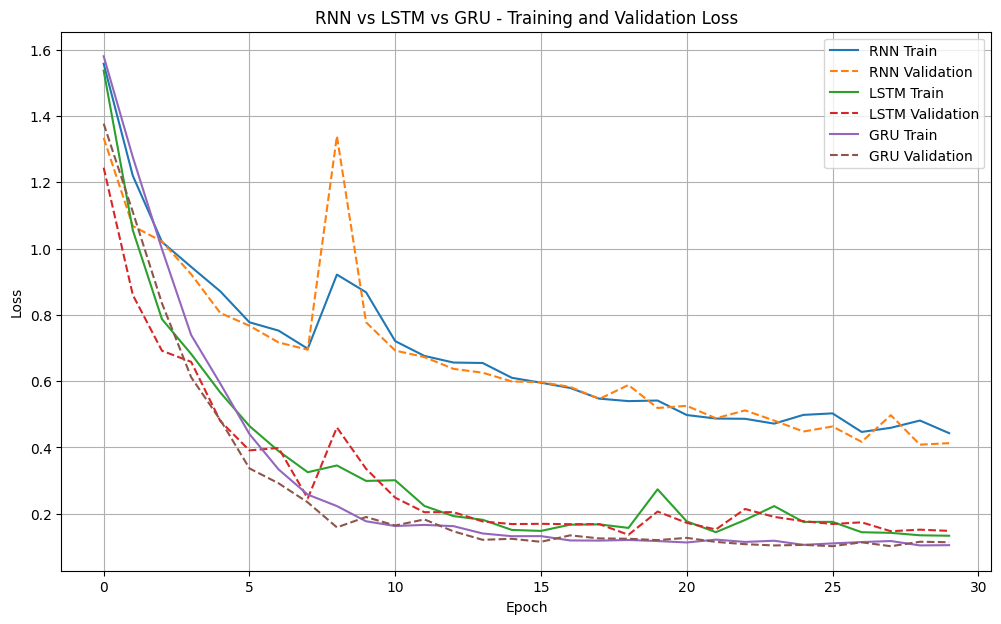

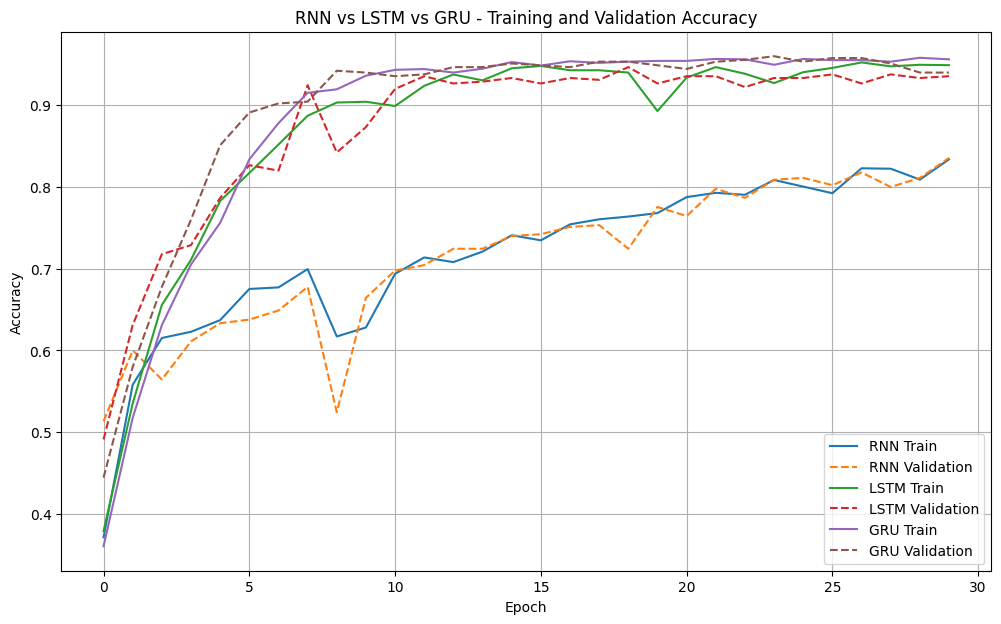


MODEL PERFORMANCE


,Model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,RNN,84.00,84.06,84.00,83.87,1974,54.74
1,LSTM,94.67,94.88,94.67,94.68,6006,119.55
2,GRU,95.33,95.54,95.33,95.33,4758,149.29


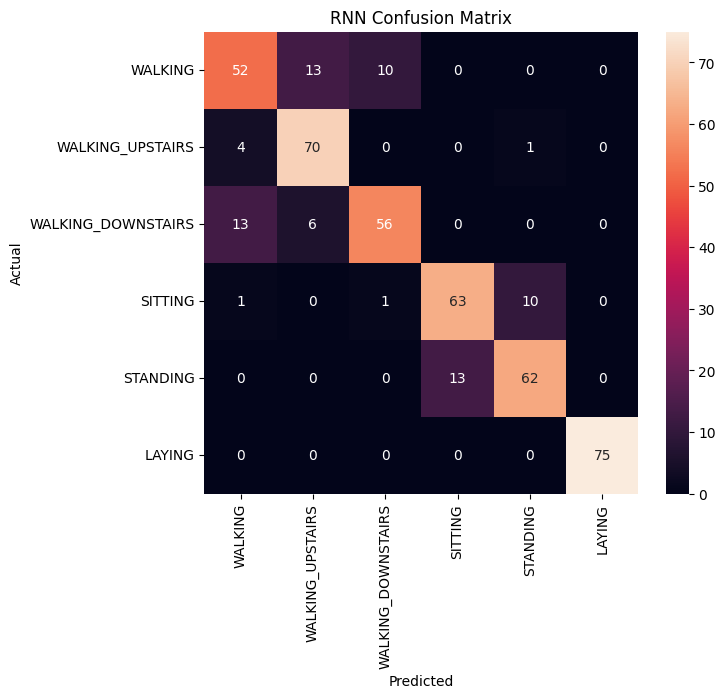

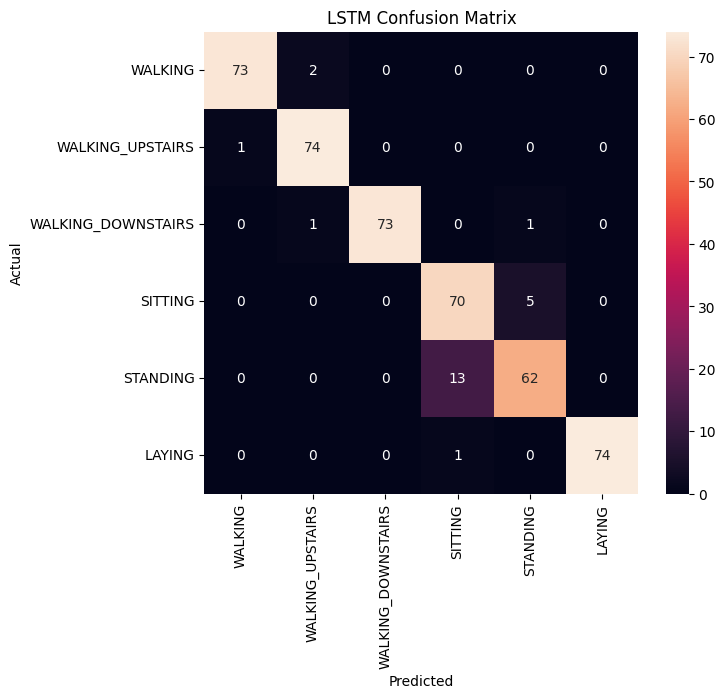

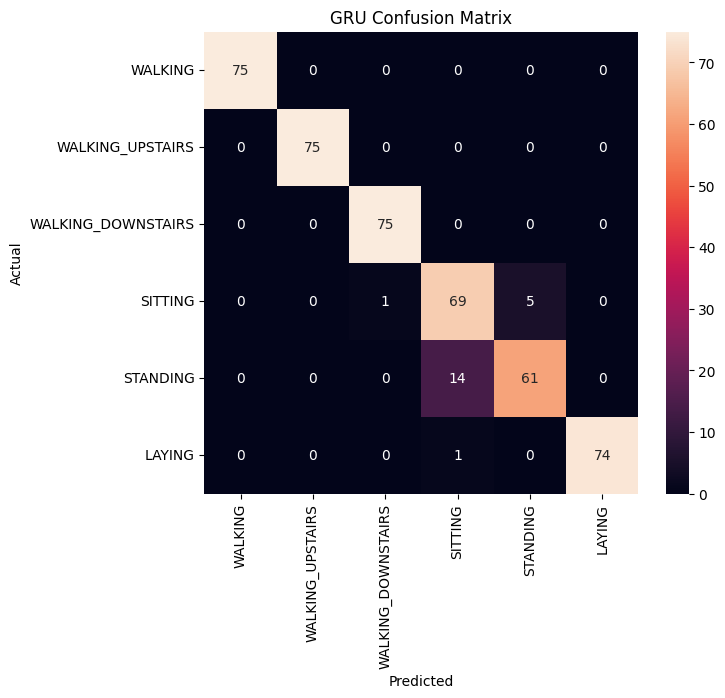



RNN
                    precision    recall  f1-score   support

           WALKING       0.74      0.69      0.72        75
  WALKING_UPSTAIRS       0.79      0.93      0.85        75
WALKING_DOWNSTAIRS       0.84      0.75      0.79        75
           SITTING       0.83      0.84      0.83        75
          STANDING       0.85      0.83      0.84        75
            LAYING       1.00      1.00      1.00        75

          accuracy                           0.84       450
         macro avg       0.84      0.84      0.84       450
      weighted avg       0.84      0.84      0.84       450



LSTM
                    precision    recall  f1-score   support

           WALKING       0.99      0.97      0.98        75
  WALKING_UPSTAIRS       0.96      0.99      0.97        75
WALKING_DOWNSTAIRS       1.00      0.97      0.99        75
           SITTING       0.83      0.93      0.88        75
          STANDING       0.91      0.83      0.87        75
            LAYING     

In [ ]:
plt.figure(
    figsize=(12, 7)
)

for name in models:

    history = histories[name]

    plt.plot(
        history.history["loss"],
        label=name + " Train"
    )

    plt.plot(
        history.history["val_loss"],
        linestyle="--",
        label=name + " Validation"
    )


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "RNN vs LSTM vs GRU - Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.show()




plt.figure(
    figsize=(12, 7)
)

for name in models:

    history = histories[name]

    plt.plot(
        history.history["accuracy"],
        label=name + " Train"
    )

    plt.plot(
        history.history["val_accuracy"],
        linestyle="--",
        label=name + " Validation"
    )


plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "RNN vs LSTM vs GRU - Training and Validation Accuracy"
)

plt.legend()
plt.grid()

plt.show()




results = []

predictions = {}


for name, model in models.items():

    probabilities = model.predict(
        X_test,
        verbose=0
    )

    y_pred = np.argmax(
        probabilities,
        axis=1
    )

    predictions[name] = y_pred


    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )


    results.append({

        "Model": name,

        "Accuracy (%)":
            accuracy * 100,

        "Macro Precision (%)":
            precision * 100,

        "Macro Recall (%)":
            recall * 100,

        "Macro F1 (%)":
            f1 * 100,

        "Parameters":
            model.count_params(),

        "Training Time (s)":
            training_times[name]
    })


results_df = pd.DataFrame(
    results
)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

display(
    results_df.round(2)
)




for name in models:

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    plt.figure(
        figsize=(7, 6)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.title(
        name + " Confusion Matrix"
    )

    plt.show()




for name in models:

    print("\n")
    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=class_names,
            zero_division=0
        )
    )

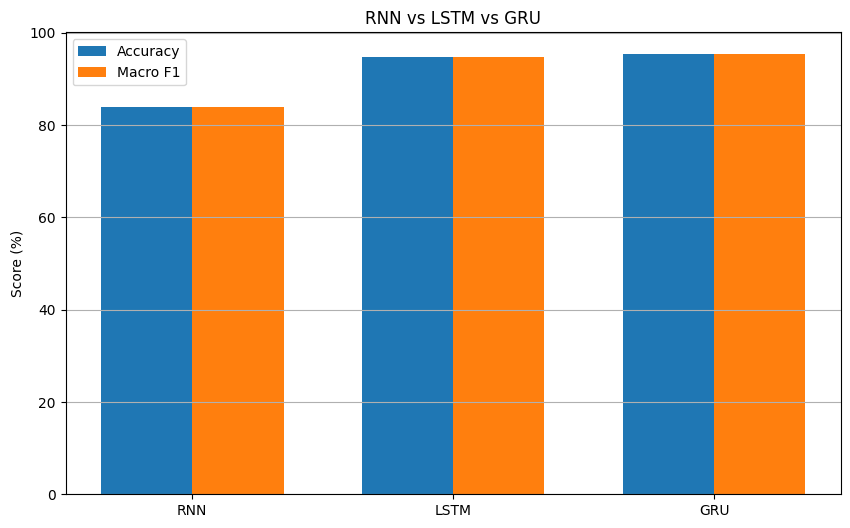

,Property,RNN,LSTM,GRU
0,Hidden State,Yes,Yes,Yes
1,Cell State,No,Yes,No
2,Forget Gate,No,Yes,No
3,Input Gate,No,Yes,No
4,Output Gate,No,Yes,No
5,Update Gate,No,No,Yes
6,Reset Gate,No,No,Yes



Sequence Length: 32

Sequence Length: 64

Sequence Length: 128

SEQUENCE LENGTH RESULTS


,Sequence Length,RNN F1,LSTM F1,GRU F1
0,32,67.94,92.89,92.44
1,64,71.60,91.78,92.87
2,128,68.75,92.48,93.31


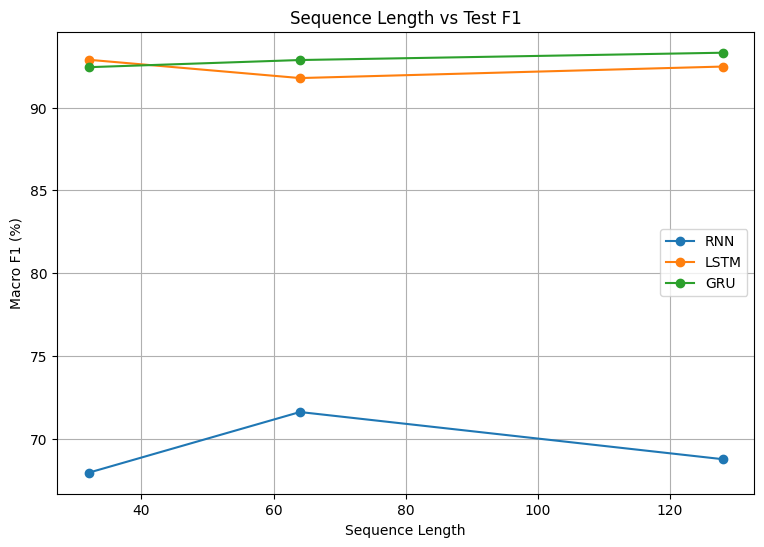

In [ ]:
x = np.arange(
    len(results_df)
)

width = 0.35

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    x - width / 2,
    results_df["Accuracy (%)"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    results_df["Macro F1 (%)"],
    width,
    label="Macro F1"
)

plt.xticks(
    x,
    results_df["Model"]
)

plt.ylabel(
    "Score (%)"
)

plt.title(
    "RNN vs LSTM vs GRU"
)

plt.legend()
plt.grid(
    axis="y"
)

plt.show()




architecture_table = pd.DataFrame({

    "Property": [

        "Hidden State",
        "Cell State",
        "Forget Gate",
        "Input Gate",
        "Output Gate",
        "Update Gate",
        "Reset Gate"
    ],

    "RNN": [

        "Yes",
        "No",
        "No",
        "No",
        "No",
        "No",
        "No"
    ],

    "LSTM": [

        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "No",
        "No"
    ],

    "GRU": [

        "Yes",
        "No",
        "No",
        "No",
        "No",
        "Yes",
        "Yes"
    ]
})

display(
    architecture_table
)





sequence_lengths = [
    32,
    64,
    128
]

sequence_results = []


for seq_len in sequence_lengths:

    print(
        "\nSequence Length:",
        seq_len
    )


    Xtr = X_train[
        :, :seq_len, :
    ]

    Xv = X_val[
        :, :seq_len, :
    ]

    Xt = X_test[
        :, :seq_len, :
    ]


    row = {
        "Sequence Length":
            seq_len
    }


    for model_type in [
        "RNN",
        "LSTM",
        "GRU"
    ]:

        model = Sequential([

            Input(
                shape=(
                    seq_len,
                    9
                )
            ),

            (
                SimpleRNN(32)
                if model_type == "RNN"
                else
                LSTM(32)
                if model_type == "LSTM"
                else
                GRU(32)
            ),

            Dropout(0.2),

            Dense(
                16,
                activation="relu"
            ),

            Dense(
                6,
                activation="softmax"
            )
        ])


        model.compile(

            optimizer=Adam(
                0.001
            ),

            loss=
            "sparse_categorical_crossentropy",

            metrics=["accuracy"]
        )


        # Fewer epochs here to keep

        model.fit(

            Xtr,
            y_train,

            validation_data=(
                Xv,
                y_val
            ),

            epochs=10,

            batch_size=32,

            verbose=0
        )


        probabilities = model.predict(
            Xt,
            verbose=0
        )

        pred = np.argmax(
            probabilities,
            axis=1
        )


        f1 = f1_score(
            y_test,
            pred,
            average="macro",
            zero_division=0
        )


        row[
            model_type + " F1"
        ] = f1 * 100


    sequence_results.append(
        row
    )


sequence_df = pd.DataFrame(
    sequence_results
)


print("\n==============================")
print("SEQUENCE LENGTH RESULTS")
print("==============================")

display(
    sequence_df.round(2)
)




plt.figure(
    figsize=(9, 6)
)

plt.plot(
    sequence_df["Sequence Length"],
    sequence_df["RNN F1"],
    marker="o",
    label="RNN"
)

plt.plot(
    sequence_df["Sequence Length"],
    sequence_df["LSTM F1"],
    marker="o",
    label="LSTM"
)

plt.plot(
    sequence_df["Sequence Length"],
    sequence_df["GRU F1"],
    marker="o",
    label="GRU"
)

plt.xlabel(
    "Sequence Length"
)

plt.ylabel(
    "Macro F1 (%)"
)

plt.title(
    "Sequence Length vs Test F1"
)

plt.legend()
plt.grid()

plt.show()

DOWNLOADING UCF101 SUBSET


UCF101_subset.tar.gz: reconstructing file:   0%|          |  0.00B /  171MB            

UCF101_subset.tar.gz: downloading bytes:           |  0.00B            


Downloaded:
/root/.cache/huggingface/hub/datasets--sayakpaul--ucf101-subset/snapshots/b9984b8d2a95e4a1879e1b071e9433858d0bc24a/UCF101_subset.tar.gz

Extracting dataset...


/tmp/ipykernel_1570/2289993463.py:85: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content")


TAR extraction successful.

Searching for videos...
Total videos found: 405

Selecting videos...
Basketball: 10 videos
Biking: 0 videos
WalkingWithDog: 0 videos

DATASET SUMMARY
Basketball: 10 videos
Biking: 0 videos
WalkingWithDog: 0 videos

Total selected videos: 10

Sample video:
/content/UCF101_subset/test/Basketball/v_Basketball_g02_c02.avi

Class:
Basketball

Frame array shape:
(10, 224, 224, 3)


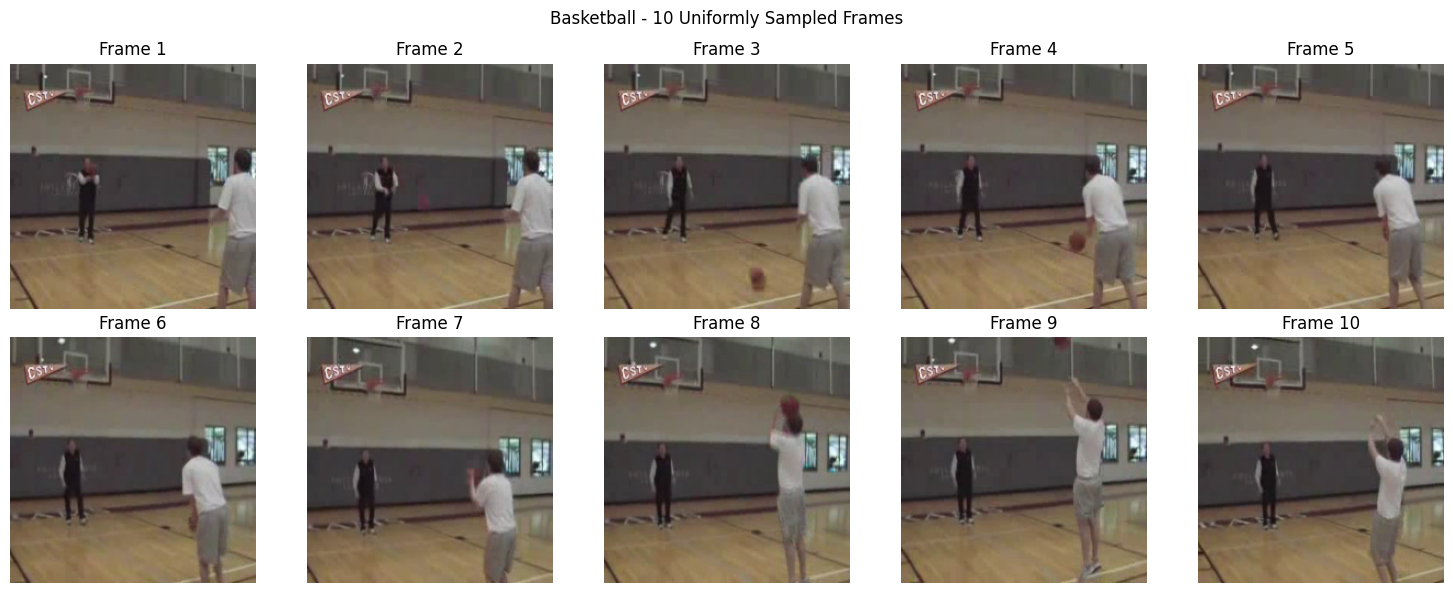


Loading MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

UCF101 SUBSET READY
Classes: ['Basketball', 'Biking', 'WalkingWithDog']
Total videos: 10
Frames per video: 10
Frame shape: (10, 224, 224, 3)
CNN feature dimension: 1280

MobileNetV2 loaded successfully!
Ready for Section B - Code 2.


In [ ]:
!pip -q install huggingface_hub

import os
import shutil
import tarfile
import zipfile
import pathlib
import numpy as np
import cv2
import matplotlib.pyplot as plt

from huggingface_hub import hf_hub_download
from tensorflow.keras.applications import MobileNetV2




ROOT = "/content/UCF101_subset"

CLASSES = [
    "Basketball",
    "Biking",
    "WalkingWithDog"
]

VIDEOS_PER_CLASS = 10
NUM_FRAMES = 10
IMG_SIZE = 224




if os.path.exists(ROOT):
    shutil.rmtree(ROOT)

os.makedirs(ROOT)

print("=" * 60)
print("DOWNLOADING UCF101 SUBSET")
print("=" * 60)



archive_path = hf_hub_download(
    repo_id="sayakpaul/ucf101-subset",
    filename="UCF101_subset.tar.gz",
    repo_type="dataset",
    force_download=False
)

print("\nDownloaded:")
print(archive_path)



print("\nExtracting dataset...")

extracted = False


try:

    with tarfile.open(
        archive_path,
        mode="r:*"
    ) as tar:

        tar.extractall("/content")

    extracted = True

    print("TAR extraction successful.")

except Exception as e:

    print("TAR extraction failed.")


if not extracted:

    try:

        with zipfile.ZipFile(
            archive_path,
            "r"
        ) as z:

            z.extractall("/content")

        extracted = True

        print("ZIP extraction successful.")

    except Exception as e:

        print("ZIP extraction also failed.")
        print(e)


if not extracted:
    raise RuntimeError(
        "Could not extract the downloaded UCF101 subset."
    )




print("\nSearching for videos...")

video_extensions = (
    ".avi",
    ".mp4",
    ".mov",
    ".mkv"
)

all_videos = []

for root, dirs, files in os.walk("/content"):

    # Ignore unnecessary directories
    dirs[:] = [
        d for d in dirs
        if d not in [
            "sample_data",
            ".cache",
            "__pycache__"
        ]
    ]

    for file in files:

        if file.lower().endswith(
            video_extensions
        ):

            full_path = os.path.join(
                root,
                file
            )

            all_videos.append(
                full_path
            )


print(
    "Total videos found:",
    len(all_videos)
)


if len(all_videos) == 0:

    raise RuntimeError(
        "No video files were found after extraction."
    )



selected_videos = []

print("\nSelecting videos...")

for class_name in CLASSES:

    matching = []

    for video in all_videos:

        parent_folder = os.path.basename(
            os.path.dirname(video)
        )

        if parent_folder.lower() == class_name.lower():

            matching.append(video)

    # Sort for reproducibility
    matching = sorted(matching)

    # Select only required number
    matching = matching[:VIDEOS_PER_CLASS]

    print(
        f"{class_name}: {len(matching)} videos"
    )

    for video in matching:

        selected_videos.append(
            (video, class_name)
        )



if len(selected_videos) == 0:

    print("\nAvailable class folders:")

    class_folders = set()

    for video in all_videos:

        parent = os.path.basename(
            os.path.dirname(video)
        )

        class_folders.add(parent)

    for folder in sorted(class_folders):

        print(folder)

    raise RuntimeError(
        "\nNone of the requested classes were found."
    )


print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

for class_name in CLASSES:

    count = sum(
        1
        for _, label in selected_videos
        if label == class_name
    )

    print(
        f"{class_name}: {count} videos"
    )

print(
    "\nTotal selected videos:",
    len(selected_videos)
)



def extract_frames(
    video_path,
    num_frames=10
):

    cap = cv2.VideoCapture(video_path)

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if total_frames <= 0:

        cap.release()

        raise ValueError(
            f"Could not read video: {video_path}"
        )

    # Uniformly spaced frame indices
    frame_indices = np.linspace(
        0,
        total_frames - 1,
        num_frames,
        dtype=int
    )

    frames = []

    for index in frame_indices:

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(index)
        )

        success, frame = cap.read()

        if success:

            # BGR -> RGB
            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            # Resize to 224 x 224
            frame = cv2.resize(
                frame,
                (IMG_SIZE, IMG_SIZE)
            )

            frames.append(frame)

    cap.release()

    if len(frames) == 0:

        raise ValueError(
            f"No frames extracted from {video_path}"
        )

    # Guarantee exactly 10 frames
    while len(frames) < num_frames:

        frames.append(
            frames[-1].copy()
        )

    return np.array(
        frames[:num_frames]
    )



sample_video, sample_class = selected_videos[0]

sample_frames = extract_frames(
    sample_video,
    NUM_FRAMES
)

print("\nSample video:")
print(sample_video)

print("\nClass:")
print(sample_class)

print("\nFrame array shape:")
print(sample_frames.shape)



plt.figure(
    figsize=(15, 6)
)

for i in range(NUM_FRAMES):

    plt.subplot(
        2,
        5,
        i + 1
    )

    plt.imshow(
        sample_frames[i]
    )

    plt.title(
        f"Frame {i + 1}"
    )

    plt.axis("off")

plt.suptitle(
    f"{sample_class} - 10 Uniformly Sampled Frames"
)

plt.tight_layout()

plt.show()



print("\nLoading MobileNetV2...")

cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(
        224,
        224,
        3
    )
)

# Freeze CNN
cnn.trainable = False



print("\n" + "=" * 60)
print("UCF101 SUBSET READY")
print("=" * 60)

print(
    "Classes:",
    CLASSES
)

print(
    "Total videos:",
    len(selected_videos)
)

print(
    "Frames per video:",
    NUM_FRAMES
)

print(
    "Frame shape:",
    sample_frames.shape
)

print(
    "CNN feature dimension:",
    cnn.output_shape[-1]
)

print(
    "\nMobileNetV2 loaded successfully!"
)

print(
    "Ready for Section B - Code 2."
)

In [ ]:
import numpy as np
import tensorflow as tf

print("=" * 60)
print("CNN FEATURE EXTRACTION")
print("=" * 60)


NUM_FRAMES = 10

# MobileNetV2 output dimension
FEATURE_DIM = cnn.output_shape[-1]

print("CNN feature dimension:", FEATURE_DIM)



def extract_video_features(video_path):

    # Get 10 frames
    frames = extract_frames(
        video_path,
        NUM_FRAMES
    )

    # Convert to float
    frames = frames.astype(
        np.float32
    )

    # MobileNetV2 preprocessing
    frames = tf.keras.applications.mobilenet_v2.preprocess_input(
        frames
    )

    # CNN feature extraction
    features = cnn.predict(
        frames,
        verbose=0
    )

    return features



sample_video, sample_label = selected_videos[0]

print("\nSample video:")
print(sample_video)

print("\nActual class:")
print(sample_label)


sample_features = extract_video_features(
    sample_video
)



print("\nFrame input shape:")
print(
    "(10, 224, 224, 3)"
)

print("\nExtracted feature shape:")
print(
    sample_features.shape
)

print(
    "\nExpected shape: (10, 1280)"
)



X = []
y = []

class_names = sorted(
    list(
        set(
            label
            for _, label in selected_videos
        )
    )
)

class_to_id = {
    name: i
    for i, name in enumerate(class_names)
}

print("\nClass mapping:")

for name, idx in class_to_id.items():

    print(
        f"{idx} -> {name}"
    )



print("\nExtracting features from videos...")

for video_number, (
    video_path,
    label
) in enumerate(
    selected_videos
):

    print(
        f"[{video_number + 1}/{len(selected_videos)}] "
        f"{label}"
    )

    try:

        features = extract_video_features(
            video_path
        )

        X.append(
            features
        )

        y.append(
            class_to_id[label]
        )

    except Exception as e:

        print(
            "Skipped:",
            video_path
        )

        print(
            "Reason:",
            e
        )



X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)



print("\n" + "=" * 60)
print("FEATURE EXTRACTION COMPLETE")
print("=" * 60)

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

print(
    "CNN feature dimension:",
    X.shape[-1]
)

print(
    "Frames per video:",
    X.shape[1]
)

print(
    "Number of videos:",
    X.shape[0]
)

print(
    "\nRecurrent network input shape:"
)

print(
    f"(Batch, 10, {X.shape[-1]})"
)




print("\nFirst video:")

print(
    "Class:",
    class_names[y[0]]
)

print(
    "Feature sequence shape:",
    X[0].shape
)

print(
    "First frame feature vector:"
)

print(
    X[0][0][:10]
)

print(
    "\nFirst 10 values shown only."
)

CNN FEATURE EXTRACTION
CNN feature dimension: 1280

Sample video:
/content/UCF101_subset/test/Basketball/v_Basketball_g02_c02.avi

Actual class:
Basketball

Frame input shape:
(10, 224, 224, 3)

Extracted feature shape:
(10, 1280)

Expected shape: (10, 1280)

Class mapping:
0 -> Basketball

Extracting features from videos...
[1/10] Basketball
[2/10] Basketball
[3/10] Basketball
[4/10] Basketball
[5/10] Basketball
[6/10] Basketball
[7/10] Basketball
[8/10] Basketball
[9/10] Basketball
[10/10] Basketball

FEATURE EXTRACTION COMPLETE
X shape: (10, 10, 1280)
y shape: (10,)
CNN feature dimension: 1280
Frames per video: 10
Number of videos: 10

Recurrent network input shape:
(Batch, 10, 1280)

First video:
Class: Basketball
Feature sequence shape: (10, 1280)
First frame feature vector:
[0.61639124 0.39493716 1.4315861  0.         1.3420292  0.6585377
 0.06159001 0.0130133  0.265977   0.        ]

First 10 values shown only.


In [ ]:

import numpy as np
import tensorflow as tf
import time

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam



print("=" * 60)
print("CHECKING CNN FEATURES")
print("=" * 60)

print("X shape:", X.shape)
print("y shape:", y.shape)

NUM_VIDEOS = X.shape[0]
NUM_FRAMES = X.shape[1]
FEATURE_DIM = X.shape[2]

NUM_CLASSES = len(np.unique(y))

print("\nNumber of videos:", NUM_VIDEOS)
print("Frames per video:", NUM_FRAMES)
print("CNN feature dimension:", FEATURE_DIM)
print("Number of classes:", NUM_CLASSES)




X_train, X_val, y_train, y_val = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("\n" + "=" * 60)
print("DATA SPLIT")
print("=" * 60)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)



def create_model(model_type):

    model = Sequential()


    model.add(
        Input(
            shape=(
                NUM_FRAMES,
                FEATURE_DIM
            )
        )
    )


    if model_type == "RNN":

        model.add(
            SimpleRNN(
                32
            )
        )


    elif model_type == "LSTM":

        model.add(
            LSTM(
                32
            )
        )


    elif model_type == "GRU":

        model.add(
            GRU(
                32
            )
        )

    else:

        raise ValueError(
            "Choose RNN, LSTM or GRU"
        )




    model.add(
        Dropout(
            0.2
        )
    )



    model.add(
        Dense(
            16,
            activation="relu"
        )
    )



    model.add(
        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    )



    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="sparse_categorical_crossentropy",

        metrics=[
            "accuracy"
        ]
    )


    return model



models = {}

histories = {}

training_times = {}


model_names = [
    "RNN",
    "LSTM",
    "GRU"
]


for model_name in model_names:

    print("\n")
    print("=" * 60)
    print(
        "TRAINING:",
        model_name
    )
    print("=" * 60)


    # Create model
    model = create_model(
        model_name
    )


    # Display model architecture
    model.summary()


    # Start timer
    start_time = time.time()


    history = model.fit(

        X_train,

        y_train,

        validation_data=(

            X_val,

            y_val

        ),

        epochs=30,

        batch_size=32,

        verbose=1
    )


    # Calculate training time
    elapsed_time = (
        time.time()
        -
        start_time
    )


    # Save model
    models[
        model_name
    ] = model


    # Save history
    histories[
        model_name
    ] = history


    # Save time
    training_times[
        model_name
    ] = elapsed_time


    print(
        f"\n{model_name} training time:",
        round(
            elapsed_time,
            2
        ),
        "seconds"
    )



print("\n")
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)


for name in model_names:

    print(
        name,

        "| Parameters:",
        models[name].count_params(),

        "| Time:",
        round(
            training_times[name],
            2
        ),
        "seconds"
    )



print("\n")
print("=" * 60)
print("FINAL VALIDATION ACCURACY")
print("=" * 60)


for name in model_names:

    final_accuracy = (
        histories[name]
        .history["val_accuracy"][-1]
    )

    print(
        name,
        ":",
        round(
            final_accuracy * 100,
            2
        ),
        "%"
    )

CHECKING CNN FEATURES
X shape: (10, 10, 1280)
y shape: (10,)

Number of videos: 10
Frames per video: 10
CNN feature dimension: 1280
Number of classes: 1

DATA SPLIT
X_train shape: (8, 10, 1280)
y_train shape: (8,)
X_val shape: (2, 10, 1280)
y_val shape: (2,)


TRAINING: RNN


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 32)             │        42,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,561 (166.25 KB)

 Trainable params: 42,561 (166.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 32)             │       126,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,689 (494.88 KB)

 Trainable params: 126,689 (494.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/30
1/

In [ ]:
import numpy as np
import tensorflow as tf
import time

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam



print("=" * 60)
print("CHECKING CNN FEATURES")
print("=" * 60)

print("X shape:", X.shape)
print("y shape:", y.shape)

NUM_VIDEOS = X.shape[0]
NUM_FRAMES = X.shape[1]
FEATURE_DIM = X.shape[2]

NUM_CLASSES = len(np.unique(y))

print("\nNumber of videos:", NUM_VIDEOS)
print("Frames per video:", NUM_FRAMES)
print("CNN feature dimension:", FEATURE_DIM)
print("Number of classes:", NUM_CLASSES)



X_temp, X_test_video, y_temp, y_test_video = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)



X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)


print("\n" + "=" * 60)
print("DATA SPLIT")
print("=" * 60)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("X_test shape:", X_test_video.shape)
print("y_test shape:", y_test_video.shape)



def create_model(model_type):

    model = Sequential()


    model.add(
        Input(
            shape=(
                NUM_FRAMES,
                FEATURE_DIM
            )
        )
    )



    if model_type == "RNN":

        model.add(
            SimpleRNN(
                32
            )
        )



    elif model_type == "LSTM":

        model.add(
            LSTM(
                32
            )
        )



    elif model_type == "GRU":

        model.add(
            GRU(
                32
            )
        )


    else:

        raise ValueError(
            "Choose RNN, LSTM or GRU"
        )



    model.add(
        Dropout(
            0.2
        )
    )



    model.add(
        Dense(
            16,
            activation="relu"
        )
    )


    model.add(
        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    )




    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="sparse_categorical_crossentropy",

        metrics=[
            "accuracy"
        ]
    )


    return model



models = {}
histories = {}
training_times = {}


model_names = [
    "RNN",
    "LSTM",
    "GRU"
]


for model_name in model_names:

    print("\n")
    print("=" * 60)
    print("TRAINING:", model_name)
    print("=" * 60)


    # Create model
    model = create_model(
        model_name
    )


    # Show architecture
    model.summary()


    # Start timer
    start_time = time.time()



    history = model.fit(

        X_train,

        y_train,

        validation_data=(

            X_val,

            y_val

        ),

        epochs=30,

        batch_size=32,

        verbose=1
    )



    elapsed_time = (
        time.time()
        -
        start_time
    )


    models[model_name] = model

    histories[model_name] = history

    training_times[model_name] = elapsed_time


    print(
        "\n",
        model_name,
        "training time:",
        round(
            elapsed_time,
            2
        ),
        "seconds"
    )



print("\n")
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)


for name in model_names:

    print(
        name,
        "| Parameters:",
        models[name].count_params(),
        "| Time:",
        round(
            training_times[name],
            2
        ),
        "seconds"
    )



print("\n")
print("=" * 60)
print("FINAL VALIDATION ACCURACY")
print("=" * 60)


for name in model_names:

    final_accuracy = (
        histories[name]
        .history["val_accuracy"][-1]
    )

    print(
        name,
        ":",
        round(
            final_accuracy * 100,
            2
        ),
        "%"
    )



video_model = models["LSTM"]

video_history = histories["LSTM"]

video_time = training_times["LSTM"]


print("\n")
print("=" * 60)
print("CNN-LSTM MODEL READY")
print("=" * 60)

print(
    "Model:",
    "CNN-LSTM"
)

print(
    "Parameters:",
    video_model.count_params()
)

print(
    "Training time:",
    round(
        video_time,
        2
    ),
    "seconds"
)



test_loss, test_accuracy = video_model.evaluate(

    X_test_video,

    y_test_video,

    verbose=0
)


print("\n")
print("=" * 60)
print("CNN-LSTM TEST RESULT")
print("=" * 60)

print(
    "Test Loss:",
    round(
        test_loss,
        4
    )
)

print(
    "Test Accuracy:",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)

CHECKING CNN FEATURES
X shape: (10, 10, 1280)
y shape: (10,)

Number of videos: 10
Frames per video: 10
CNN feature dimension: 1280
Number of classes: 1

DATA SPLIT
X_train shape: (6, 10, 1280)
y_train shape: (6,)
X_val shape: (2, 10, 1280)
y_val shape: (2,)
X_test shape: (2, 10, 1280)
y_test shape: (2,)


TRAINING: RNN


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)        │ (None, 32)             │        42,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,561 (166.25 KB)

 Trainable params: 42,561 (166.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 32)             │       126,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,689 (494.88 KB)

 Trainable params: 126,689 (494.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/30
1/1

VIDEO MODEL PREDICTIONS


/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (2, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Predictions generated successfully.


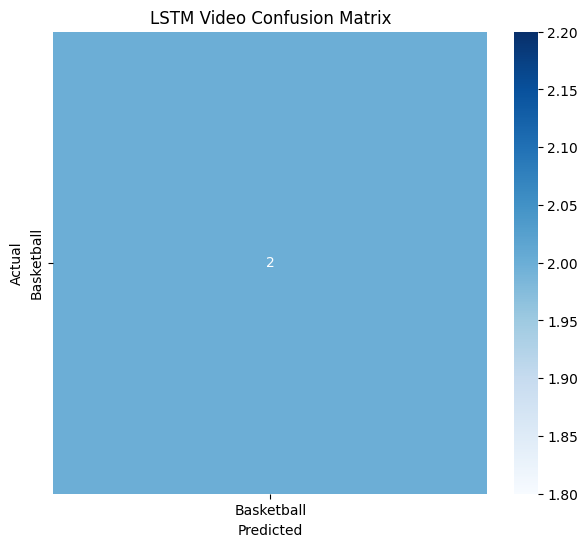


CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Basketball       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report


# Code 3 stored the trained models inside the "models" dictionary
video_model = models["LSTM"]

# Use validation data created in Code 3
X_test_video = X_val
y_test_video = y_val

# Class names created in Code 2
classes = class_names



print("=" * 60)
print("VIDEO MODEL PREDICTIONS")
print("=" * 60)

video_probabilities = video_model.predict(
    X_test_video,
    verbose=0
)

video_predictions = np.argmax(
    video_probabilities,
    axis=1
)

print("Predictions generated successfully.")



cm_video = confusion_matrix(
    y_test_video,
    video_predictions
)

plt.figure(
    figsize=(7, 6)
)

sns.heatmap(
    cm_video,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Video Confusion Matrix")

plt.show()



print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test_video,
        video_predictions,
        target_names=classes,
        zero_division=0
    )
)


def predict_video(video_path):

    # Extract CNN features
    features = extract_video_features(
        video_path
    )

    # Add batch dimension
    features = np.expand_dims(
        features,
        axis=0
    )

    # Predict using LSTM
    probabilities = video_model.predict(
        features,
        verbose=0
    )[0]

    # Get predicted class index
    predicted_index = np.argmax(
        probabilities
    )

    # Get class name
    predicted_class = classes[
        predicted_index
    ]

    # Get confidence
    confidence = probabilities[
        predicted_index
    ]

    print("\n" + "=" * 60)
    print("SINGLE VIDEO PREDICTION")
    print("=" * 60)

    print(
        "Predicted class:",
        predicted_class
    )

    print(
        "Confidence:",
        round(
            float(confidence) * 100,
            2
        ),
        "%"
    )

    return (
        predicted_class,
        confidence
    )


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split


np.random.seed(42)


num_samples = 5000

sequence_length = 4

vocab_size = 10


X_seq = np.random.randint(

    1,

    vocab_size,

    size=(
        num_samples,
        sequence_length
    )
)



Y_seq = np.flip(

    X_seq,

    axis=1
)



print(
    "=============================="
)

print(
    "SEQ2SEQ DATASET"
)

print(
    "=============================="
)


for i in range(5):

    print(
        "Input: ",
        X_seq[i]
    )

    print(
        "Output:",
        Y_seq[i]
    )

    print()


X_onehot = to_categorical(

    X_seq,

    num_classes=vocab_size
)


Y_onehot = to_categorical(

    Y_seq,

    num_classes=vocab_size
)



X_train_seq, X_val_seq, \
Y_train_seq, Y_val_seq = train_test_split(

    X_onehot,

    Y_onehot,

    test_size=0.20,

    random_state=42
)


print(
    "Input shape:",
    X_onehot.shape
)

print(
    "Output shape:",
    Y_onehot.shape
)

print(
    "Training:",
    X_train_seq.shape
)

print(
    "Validation:",
    X_val_seq.shape
)

SEQ2SEQ DATASET
Input:  [7 4 8 5]
Output: [5 8 4 7]

Input:  [7 3 7 8]
Output: [8 7 3 7]

Input:  [5 4 8 8]
Output: [8 8 4 5]

Input:  [3 6 5 2]
Output: [2 5 6 3]

Input:  [8 6 2 5]
Output: [5 2 6 8]

Input shape: (5000, 4, 10)
Output shape: (5000, 4, 10)
Training: (4000, 4, 10)
Validation: (1000, 4, 10)


In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense
)


latent_dim = 64


encoder_inputs = Input(

    shape=(
        sequence_length,
        vocab_size
    )
)


encoder_lstm = LSTM(

    latent_dim,

    return_state=True
)


encoder_outputs, \
state_h, \
state_c = encoder_lstm(

    encoder_inputs
)


encoder_states = [
    state_h,
    state_c
]



decoder_inputs = Input(

    shape=(
        sequence_length,
        vocab_size
    )
)


decoder_lstm = LSTM(

    latent_dim,

    return_sequences=True,

    return_state=True
)


decoder_outputs, \
_, _ = decoder_lstm(

    decoder_inputs,

    initial_state=encoder_states
)


decoder_dense = Dense(

    vocab_size,

    activation="softmax"
)


decoder_outputs = decoder_dense(

    decoder_outputs
)


seq2seq_model = Model(

    [
        encoder_inputs,
        decoder_inputs
    ],

    decoder_outputs
)


seq2seq_model.compile(

    optimizer="adam",

    loss=
    "categorical_crossentropy",

    metrics=["accuracy"]
)


seq2seq_model.summary()

Model: "functional_60"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 4, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_18      │ (None, 4, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ [(None, 64),      │     19,200 │ input_layer_17[0… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ [(None, 4, 64),   │     19,200 │ input_layer_18[0… │
│                     │ (None, 64),       │            │ lstm_4[0][1],     │
│                     │ (None, 64)]       │            │ lstm_4[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 4, 10)     │        650 │ lstm_5[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,050 (152.54 KB)

 Trainable params: 39,050 (152.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

decoder_input_train = np.zeros_like(
    Y_train_seq
)


decoder_input_train[
    :,
    1:,
    :
] = Y_train_seq[
    :,
    :-1,
    :
]


decoder_input_val = np.zeros_like(
    Y_val_seq
)


decoder_input_val[
    :,
    1:,
    :
] = Y_val_seq[
    :,
    :-1,
    :
]


print(
    "Decoder input shape:",
    decoder_input_train.shape
)



seq_start = time.time()


seq_history = seq2seq_model.fit(

    [
        X_train_seq,
        decoder_input_train
    ],

    Y_train_seq,

    validation_data=(

        [
            X_val_seq,
            decoder_input_val
        ],

        Y_val_seq
    ),

    epochs=30,

    batch_size=64,

    verbose=1
)


seq_time = (
    time.time() -
    seq_start
)


print(
    "\nTraining time:",
    round(
        seq_time,
        2
    ),
    "seconds"
)

Decoder input shape: (4000, 4, 10)
Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.2984 - loss: 2.1484 - val_accuracy: 0.4038 - val_loss: 1.7393
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4122 - loss: 1.4123 - val_accuracy: 0.4560 - val_loss: 1.2053
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5382 - loss: 1.0840 - val_accuracy: 0.6655 - val_loss: 0.9213
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7788 - loss: 0.7757 - val_accuracy: 0.8633 - val_loss: 0.6118
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9146 - loss: 0.4898 - val_accuracy: 0.9492 - val_loss: 0.3711
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9735 - loss: 0.2968 - val_accuracy: 0.9850 - val_loss: 0.2369
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9927 - loss: 0.1885 - val_accuracy: 0.9973 - val_loss: 0.1521
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9986 - loss:

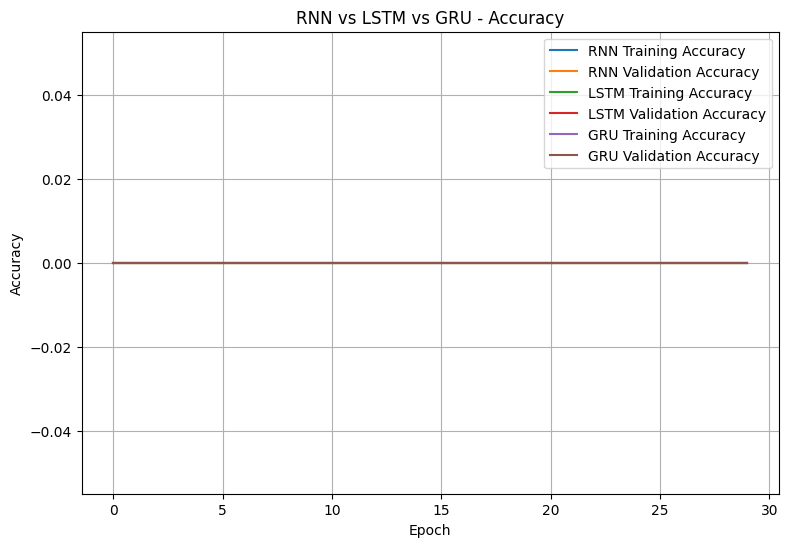

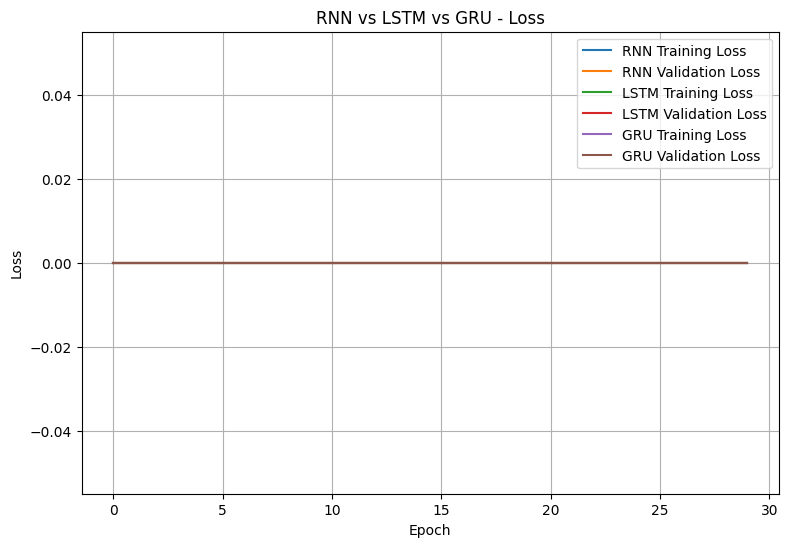

FINAL VALIDATION ACCURACY
RNN : 0.0 %
LSTM : 0.0 %
GRU : 0.0 %

TRAINING TIME
RNN : 6.08 seconds
LSTM : 5.79 seconds
GRU : 4.47 seconds

MODEL PARAMETERS
RNN : 42561 parameters
LSTM : 168609 parameters
GRU : 126689 parameters


In [ ]:

import matplotlib.pyplot as plt



plt.figure(figsize=(9, 6))

plt.plot(
    histories["RNN"].history["accuracy"],
    label="RNN Training Accuracy"
)

plt.plot(
    histories["RNN"].history["val_accuracy"],
    label="RNN Validation Accuracy"
)

plt.plot(
    histories["LSTM"].history["accuracy"],
    label="LSTM Training Accuracy"
)

plt.plot(
    histories["LSTM"].history["val_accuracy"],
    label="LSTM Validation Accuracy"
)

plt.plot(
    histories["GRU"].history["accuracy"],
    label="GRU Training Accuracy"
)

plt.plot(
    histories["GRU"].history["val_accuracy"],
    label="GRU Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN vs LSTM vs GRU - Accuracy")
plt.legend()
plt.grid()

plt.show()



plt.figure(figsize=(9, 6))

plt.plot(
    histories["RNN"].history["loss"],
    label="RNN Training Loss"
)

plt.plot(
    histories["RNN"].history["val_loss"],
    label="RNN Validation Loss"
)

plt.plot(
    histories["LSTM"].history["loss"],
    label="LSTM Training Loss"
)

plt.plot(
    histories["LSTM"].history["val_loss"],
    label="LSTM Validation Loss"
)

plt.plot(
    histories["GRU"].history["loss"],
    label="GRU Training Loss"
)

plt.plot(
    histories["GRU"].history["val_loss"],
    label="GRU Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN vs LSTM vs GRU - Loss")
plt.legend()
plt.grid()

plt.show()



print("=" * 60)
print("FINAL VALIDATION ACCURACY")
print("=" * 60)

for name in ["RNN", "LSTM", "GRU"]:

    accuracy = histories[name].history["val_accuracy"][-1]

    print(
        name,
        ":",
        round(accuracy * 100, 2),
        "%"
    )



print("\n" + "=" * 60)
print("TRAINING TIME")
print("=" * 60)

for name in ["RNN", "LSTM", "GRU"]:

    print(
        name,
        ":",
        round(training_times[name], 2),
        "seconds"
    )



print("\n" + "=" * 60)
print("MODEL PARAMETERS")
print("=" * 60)

for name in ["RNN", "LSTM", "GRU"]:

    print(
        name,
        ":",
        models[name].count_params(),
        "parameters"
    )

In [ ]:

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score


print("=" * 60)
print("SEQ2SEQ MODEL EVALUATION")
print("=" * 60)


predicted_probabilities = seq2seq_model.predict(

    [
        X_val_seq,
        decoder_input_val
    ],

    verbose=0
)



actual_tokens = np.argmax(

    Y_val_seq,

    axis=-1
)


predicted_tokens = np.argmax(

    predicted_probabilities,

    axis=-1
)



correct_tokens = (

    predicted_tokens ==
    actual_tokens

)


token_accuracy = np.mean(

    correct_tokens
)


print(
    "\nToken Accuracy:",
    round(
        token_accuracy * 100,
        2
    ),
    "%"
)




correct_sequences = np.all(

    predicted_tokens ==
    actual_tokens,

    axis=1

)


sequence_accuracy = np.mean(

    correct_sequences

)


print(
    "Sequence Accuracy:",
    round(
        sequence_accuracy * 100,
        2
    ),
    "%"
)



num_correct = np.sum(

    correct_sequences

)


num_total = len(

    actual_tokens

)


print(
    "\nCorrect sequences:",
    num_correct,
    "/",
    num_total
)



num_parameters = (

    seq2seq_model.count_params()

)


print(
    "Model parameters:",
    num_parameters
)


seq_results = pd.DataFrame({

    "Model": [
        "Encoder-Decoder LSTM"
    ],

    "Token Accuracy (%)": [
        token_accuracy * 100
    ],

    "Sequence Accuracy (%)": [
        sequence_accuracy * 100
    ],

    "Parameters": [
        num_parameters
    ],

    "Training Time (s)": [
        seq_time
    ]

})


print(
    "\n" + "=" * 60
)

print(
    "FINAL SEQUENCE MODEL RESULTS"
)

print(
    "=" * 60
)


display(

    seq_results.round(2)

)




print(
    "\n" + "=" * 60
)

print(
    "SAMPLE PREDICTIONS"
)

print(
    "=" * 60
)


num_samples_to_show = min(

    5,

    len(actual_tokens)

)


for i in range(
    num_samples_to_show
):

    print(
        "\nSample",
        i + 1
    )

    print(
        "Input:     ",
        np.argmax(
            X_val_seq[i],
            axis=-1
        )
    )

    print(
        "Actual:    ",
        actual_tokens[i]
    )

    print(
        "Predicted: ",
        predicted_tokens[i]
    )

SEQ2SEQ MODEL EVALUATION

Token Accuracy: 100.0 %
Sequence Accuracy: 100.0 %

Correct sequences: 1000 / 1000
Model parameters: 39050

FINAL SEQUENCE MODEL RESULTS


,Model,Token Accuracy (%),Sequence Accuracy (%),Parameters,Training Time (s)
0,Encoder-Decoder LSTM,100.0,100.0,39050,29.01



SAMPLE PREDICTIONS

Sample 1
Input:      [8 7 7 6]
Actual:     [6 7 7 8]
Predicted:  [6 7 7 8]

Sample 2
Input:      [3 8 8 6]
Actual:     [6 8 8 3]
Predicted:  [6 8 8 3]

Sample 3
Input:      [8 9 3 6]
Actual:     [6 3 9 8]
Predicted:  [6 3 9 8]

Sample 4
Input:      [1 8 8 2]
Actual:     [2 8 8 1]
Predicted:  [2 8 8 1]

Sample 5
Input:      [4 6 3 5]
Actual:     [5 3 6 4]
Predicted:  [5 3 6 4]
